In [56]:
import pandas as pd

In [57]:
# link to download: https://www.kaggle.com/datasets/yasserh/titanic-dataset?select=Titanic-Dataset.csv

df = pd.read_csv('Titanic-Dataset.csv')

In [58]:
df.shape

(891, 12)

In [59]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**List of features:**
* survival: Survival (0 = No, 1 = Yes)
* pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
* sex: Sex	
* Age: Age in years	
* sibsp: # of siblings / spouses aboard the Titanic	
* parch: # of parents / children aboard the Titanic	
* ticket: #	Ticket number	
* fare:	Passenger fare	
* cabin: Cabin number	
* embarked:	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


We are going to resolve these issues:
* Age, Cabin, and Embarked have NULL values => **Cleaning data** (remove NULL, remove outliers, correction) 
* Some features can be combined, such as number of siblings and number of parents onboard
* Some features are continuous, while they can be treated as categorical
* Map all categorical features into numeric type => **Feature Engineering**
* Only some features are relevant

<Axes: xlabel='Survived'>

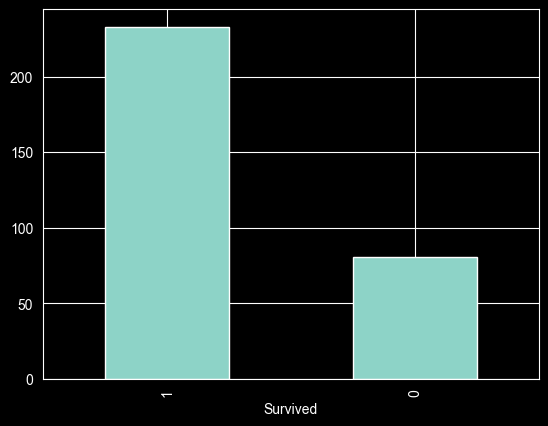

In [61]:
df['Survived'][df['Sex'] == 'female'].value_counts().plot(kind='bar')

<Axes: xlabel='Survived'>

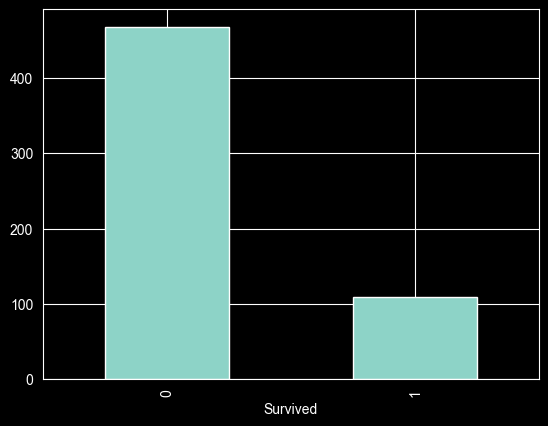

In [62]:
df['Survived'][df['Sex'] == 'male'].value_counts().plot(kind='bar')

<Axes: >

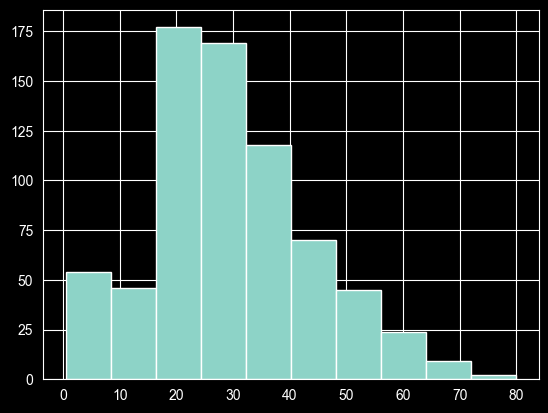

In [63]:
df['Age'].hist()

In [64]:
# TODO: Drop all rows which contain NaN value. Save to a new DataFrame
df_not_null = df.dropna(how='any', axis=0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [65]:
# Fill all NULLS in the Embarked column with its mode
mode = df['Embarked'].value_counts().index[0]
df['Embarked'] = df['Embarked'].fillna(mode)

In [66]:
# Fill all NULLS in the Age column with the median of all Age values
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)

In [67]:
# df.drop(['Cabin'], axis=1, inplace=True)

In [68]:
# Create new feature "FamilySize": sum of SibSp, Parch and the Person himself
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head()
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [69]:
# Create new feature "IsAlone": 1 if FamilySize == 1 else 0
df['IsAlone'] = (df['FamilySize'] == 1).astype('int')

In [70]:
# Age is now a continous value, categorize this feature into groups.
# For example: Age <= 18: group 1, Age in (18, 60): group 2, Age >= 60: group 3

def binning_age(x):
    if x < 18: return 0
    elif 18 <= x < 60: return 1
    else: return 2
df['Age'] = df['Age'].apply(binning_age)

# df['new_Age'] = df['Age']
# df.loc[df['Age'] < 18, 'new_Age'] = 0
# df.loc[(df['Age'] >= 18) & (df['Age'] < 60), 'new_Age'] = 1
# df.loc[df['Age'] >= 60, 'new_Age'] = 2

# df['new_Age'] = pd.cut(df['Age'], bins=3, labels=[0, 1, 2])
# df['new_Age'].value_counts()

# df['new_Age'] = pd.qcut(df['Age'], q=3, labels=[0, 1, 2])
# df['new_Age'].value_counts()

In [71]:
df['Fare'] = pd.cut(df['Fare'], bins=[0, 50, 100, float('inf')], labels=[0, 1, 2])

In [72]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1,1,0,A/5 21171,0,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,1,0,PC 17599,1,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1,0,0,STON/O2. 3101282,0,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,1,0,113803,1,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,1,0,0,373450,0,NaN,S,1,1


In [73]:
# Map all categorical features to numeric type
df['Sex'] = pd.Categorical(df['Sex'])
df['Sex'] = df['Sex'].cat.codes

In [74]:
df['Embarked'] = pd.Categorical(df['Embarked'])
df['Embarked'] = df['Embarked'].cat.codes

In [75]:
# Drop PassengerId, Name, Ticket, SibSp, Parch, Cabin
df.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Cabin'], axis=1, inplace=True)

In [76]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,1,0,2,2,0
1,1,1,0,1,1,0,2,0
2,1,3,0,1,0,2,1,1
3,1,1,0,1,1,2,2,0
4,0,3,1,1,0,2,1,1


In [77]:
df['Fare'].value_counts()

Fare
0    716
1    107
2     53
Name: count, dtype: int64

In [78]:
df.corr()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
Survived,1.000000,-0.338481,-0.543351,-0.124257,0.275904,-0.167675,0.016639,-0.203367
Pclass,-0.338481,1.000000,0.131900,-0.179506,-0.606596,0.162098,0.065997,0.135207
Sex,-0.543351,0.131900,1.000000,0.124860,-0.192452,0.108262,-0.200988,0.303646
Age,-0.124257,-0.179506,0.124860,1.000000,0.059764,0.009911,-0.347895,0.290262
Fare,0.275904,-0.606596,-0.192452,0.059764,1.000000,-0.211975,0.163145,-0.273464
Embarked,-0.167675,0.162098,0.108262,0.009911,-0.211975,1.000000,0.066516,0.063532
FamilySize,0.016639,0.065997,-0.200988,-0.347895,0.163145,0.066516,1.000000,-0.690922
IsAlone,-0.203367,0.135207,0.303646,0.290262,-0.273464,0.063532,-0.690922,1.000000


In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

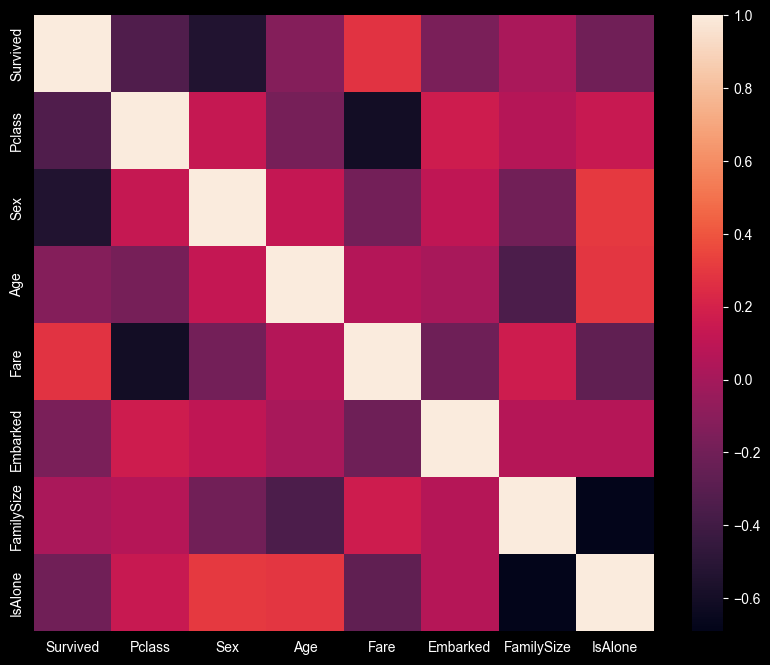

In [80]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr())

In [81]:
df.cov()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
Survived,0.236772,-0.137703,-0.126376,-0.023153,0.074384,-0.064578,0.013063,-0.048451
Pclass,-0.137703,0.699015,0.052712,-0.057470,-0.280125,0.107269,0.089028,0.055347
Sex,-0.126376,0.052712,0.228475,0.022854,-0.051029,0.040959,-0.155006,0.071063
Age,-0.023153,-0.057470,0.022854,0.146635,0.012748,0.003004,-0.214943,0.054421
Fare,0.074384,-0.280125,-0.051029,0.012748,0.305382,-0.093233,0.146309,-0.074200
Embarked,-0.064578,0.107269,0.040959,0.003004,-0.093233,0.626477,0.084944,0.024621
FamilySize,0.013063,0.089028,-0.155006,-0.214943,0.146309,0.084944,2.603248,-0.545810
IsAlone,-0.048451,0.055347,0.071063,0.054421,-0.074200,0.024621,-0.545810,0.239723
